LIBRARIES

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torchvision.models import SqueezeNet1_1_Weights
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

INPUTS

In [22]:
IMG_HEIGHT =224
IMG_WIDTH =224
IMG_CHANNELS =3
CLASS_NAMES=["lilly", "lotus", "orchid", "sunflower", "tulip"]

In [23]:
transform= transforms.Compose([
    transforms.Resize(size=(IMG_HEIGHT, IMG_WIDTH)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(size=(IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
train_dir=r"C:\My Folder\Projects\Computer_Vision\flower_images\train"
val_dir = r"C:\My Folder\Projects\Computer_Vision\flower_images\val"

train_data=datasets.ImageFolder(root=train_dir, transform=transform)
val_data =datasets.ImageFolder(root=val_dir, transform=transform)

train_dataset=DataLoader(train_data, batch_size=16, shuffle=True)
val_dataset= DataLoader(val_data, batch_size=16)

NETWORK ARCHITECTURE

In [24]:
model =models.squeezenet1_1(weights=SqueezeNet1_1_Weights.DEFAULT)

model.classifier[1] = nn.Conv2d(in_channels=512, out_channels=len(CLASS_NAMES), kernel_size=1)

for param in model.parameters():
    param.requires_grad = False

for param in model.classifier[1].parameters():
    param.requires_grad=True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
googlenet = model.to(device)

In [25]:
learning_rate=0.001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(googlenet.parameters(), lr=learning_rate)

In [26]:
def train_model(model, criterion, optimizer, train_loader, val_loader, epochs, device):
    train_loss =[]
    train_acc=[]
    val_loss=[]
    val_acc=[]
    for epoch in range(epochs):
        model.train()
        total_loss =0
        total_samples=0
        correct_preds=0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            batch_pred = (preds==labels).sum().item()
            correct_preds +=batch_pred
            total_samples+=labels.size(0)
            total_loss += loss.item()
        
        acc = correct_preds/total_samples
        print(f"Epoch {epoch+1}: Loss : {total_loss:.4f}, Accuracy : {acc:.4f}")
        train_loss.append(total_loss)
        train_acc.append(acc)
        model.eval()
        with torch.no_grad():
            eval_total_loss =0
            eval_total_samples =0
            eval_total_preds =0
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                eval_total_preds += (preds==labels).sum().item()
                eval_total_loss += loss.item()
                eval_total_samples += labels.size(0)
            eval_acc = eval_total_preds/eval_total_samples
            print(f"Val_Loss: {eval_total_loss:.4f}, Val_Accuracy : {eval_acc:.4f}")
            val_loss.append(eval_total_loss)
            val_acc.append(eval_acc)
    
    return train_loss, train_acc, val_loss, val_acc

TRAINING

In [27]:
EPOCHS = 10
train_loss, train_acc, val_loss, val_acc = train_model(model, criterion, optimizer, train_dataset, val_dataset, EPOCHS, device)

Epoch 1: Loss : 142.9135, Accuracy : 0.7203
Val_Loss: 30.2118, Val_Accuracy : 0.8250
Epoch 2: Loss : 80.0236, Accuracy : 0.8527
Val_Loss: 25.9310, Val_Accuracy : 0.8600
Epoch 3: Loss : 67.7541, Accuracy : 0.8720
Val_Loss: 25.1217, Val_Accuracy : 0.8730
Epoch 4: Loss : 60.4685, Accuracy : 0.8943
Val_Loss: 21.2183, Val_Accuracy : 0.8930
Epoch 5: Loss : 54.9212, Accuracy : 0.8983
Val_Loss: 20.7222, Val_Accuracy : 0.8980
Epoch 6: Loss : 51.7004, Accuracy : 0.9080
Val_Loss: 20.3579, Val_Accuracy : 0.8900
Epoch 7: Loss : 48.5468, Accuracy : 0.9103
Val_Loss: 20.6020, Val_Accuracy : 0.9000
Epoch 8: Loss : 47.3257, Accuracy : 0.9050
Val_Loss: 19.5637, Val_Accuracy : 0.9020
Epoch 9: Loss : 43.5650, Accuracy : 0.9193
Val_Loss: 19.8212, Val_Accuracy : 0.8990
Epoch 10: Loss : 40.3309, Accuracy : 0.9310
Val_Loss: 20.2087, Val_Accuracy : 0.8900


PLOTTING

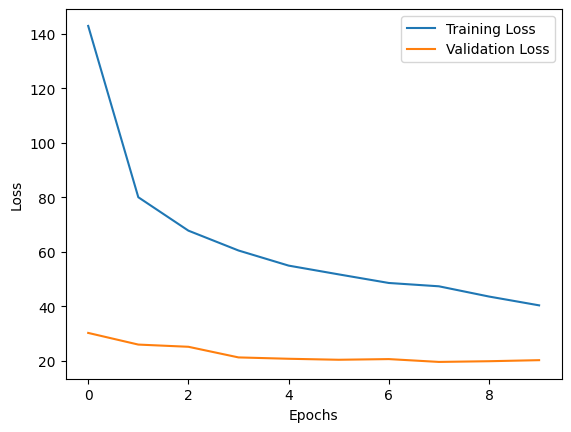

In [28]:
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

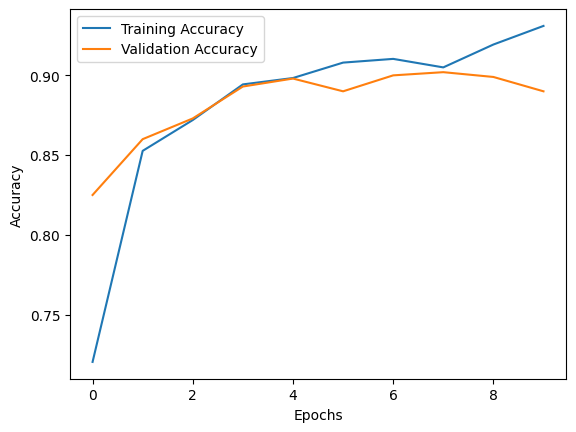

In [29]:
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()